# Calculate error bars by fitting with curve_fit method

In [1]:
from importlib import reload
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.stats import norm
from scipy import interpolate
from scipy.optimize import minimize
from time import time
from scipy.optimize import curve_fit
import scipy.constants as cs
from datetime import datetime
from scipy.io import savemat,loadmat
import os
import shutil
import json
from scipy.signal import find_peaks
%matplotlib notebook

In [7]:
def rotatedata(I,Q,angle):
    C = np.cos(angle)
    S = np.sin(angle)
    I_rotated = I * C - Q * S
    Q_rotated = I * S + Q * C
    return I_rotated,Q_rotated

def minimizeQ(angle,I,Q):
    I_rotated, Q_rotated = rotatedata(I,Q,angle)
    return abs(np.max(Q_rotated)-np.min(Q_rotated)) # Make Q as flat as possible
    #This function works for Rabi
    #All need same angle
    #Use function for Rabi, use rotation angle on all the others T1, T2, IQ blobs

## T2

In [27]:
folder = r'.\\'
subfolder = r'Fig_4b\\T2_externally_triggered\\'
Ramseyfile = 'T2ext_10Hz_17mK_WinAOM25dBm_Refl_LowPowerJPA0p85dBm8p621GHZ_avg2000_long_readout_pulse_pi_half_2023_10_14-15-43-07.mat'
# Ramseyfile = 'T2ext_50Hz_34mK_WinAOM25dBm_Refl_LowPowerJPA0p85dBm8p621GHZ_avg2000_long_readout_pulse_pi_half_2023_10_15-12-47-13.mat'
# Ramseyfile = 'T2ext_250Hz_73mK_WinAOM25dBm_Refl_LowPowerJPA0p85dBm8p621GHZ_avg2000_long_readout_pulse_pi_half_2023_10_15-20-58-27.mat'
# Ramseyfile = 'T2ext_500Hz103mK_WinAOM25dBm_Refl_LowPowerJPA0p85dBm8p621GHZ_avg2000_long_readout_pulse_pi_half_2023_10_15-16-55-54.mat'
# Ramseyfile = 'T2ext_1000Hz_144mK_WinAOM25dBm_Refl_LowPowerJPA0p85dBm8p621GHZ_avg2000_long_readout_pulse_pi_half_2023_10_15-04-19-44.mat'

# subfolder = r'Fig_4b\\T2_internally_triggered\\'
# Ramseyfile = 'T2int_10Hz_16p2mK_WinAOM24dBm_JPAon8p621GHz0p85dBm_avg4000_long_readout_pulse_pi_half_2023_09_25-14-36-05.mat'

if os.path.isdir(folder + subfolder):
    print('Folder: ' + folder + subfolder + ' found')



print('Number of alpha-numeric in file path: ' + str(len(folder + subfolder + Ramseyfile)))
data = loadmat(folder + subfolder + Ramseyfile)
I = data['I'][0]
Q = data['Q'][0]

taus = data['t_ns'][0]/4
filename = Ramseyfile

freq_det = 2.0e6
rotation_angle = 90*np.pi/180

res = minimize(minimizeQ, x0 = [0.5],args = (I,Q))
rotation_angle_test = res.x[0]
print('rotated by: ' + str(rotation_angle_test) + ' rad')
print('rotated by: ' + str(180/np.pi*rotation_angle_test) + ' deg')
I_rot,Q_rot = rotatedata(I,Q,rotation_angle_test)


Folder: .\\Fig_4b\\T2_externally_triggered\\ found
Number of alpha-numeric in file path: 154
rotated by: -0.11053171439900517 rad
rotated by: -6.333000737408387 deg


boundslow: [-6.112164662624491e-05, 100, 0, -4, -6.112164662624491e-05]
boundshigh: [0.00011905752934573293, 3000000, 0.2, 4, 5.9528764672866466e-05]


<IPython.core.display.Javascript object>


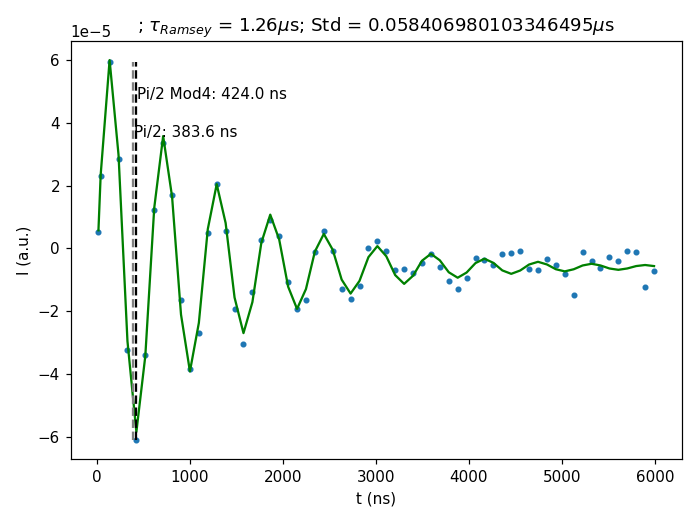

pguess [6.413342464546613e-05, 1000, 0.0052429783938414435, 1.5707963267948966, -7.964409766892232e-07]
[ 7.38333384e-05  1.25768909e+03  1.09189256e-02 -1.31527448e-02
 -5.93790906e-06]
Fit successful
383.6265926030431
424.0
np.diag(pcov)[6.02571018e-12 3.41137532e+03 1.07978782e-09 6.62480177e-04
 1.46343641e-13]
perr = np.sqrt(np.diag(pcov))
perr: [2.45473220e-06 5.84069801e+01 3.28601251e-05 2.57386903e-02
 3.82548874e-07]
A0, tau2, omega, phi, B0: [ 7.38333384e-05  1.25768909e+03  1.09189256e-02 -1.31527448e-02
 -5.93790906e-06]
Covariance matrix: [[ 6.02571018e-12 -1.03378729e-04  9.91577975e-12 -1.26009391e-08
  -8.66237852e-14]
 [-1.03378729e-04  3.41137532e+03 -1.68330761e-04  2.14787504e-01
   1.41069720e-06]
 [ 9.91577975e-12 -1.68330761e-04  1.07978782e-09 -5.30660764e-07
   6.04627737e-13]
 [-1.26009391e-08  2.14787504e-01 -5.30660764e-07  6.62480177e-04
  -6.92772646e-10]
 [-8.66237852e-14  1.41069720e-06  6.04627737e-13 -6.92772646e-10
   1.46343641e-13]]
Variance tau: 3

In [28]:
def fitfunction(t, A0, tau2, omega, phi, B0):
    if freq_det == 0:
        y = A0*np.exp(-t/tau2)*np.sin(0*omega*t+phi)+B0
    else:
        y = A0*np.exp(-t/tau2)*np.sin(omega*t+phi)+B0
    return y

xdatafit = 4*taus
ydatafit = I_rot
tvec = taus

pguess = [(np.max(ydatafit)-np.mean(ydatafit)), 1000, 2*np.pi/(4*np.max(tvec)/5),np.pi/2*np.sign(ydatafit[0]-np.mean(ydatafit)),np.min(ydatafit)+(np.max(ydatafit)-np.min(ydatafit))/2]
boundslow = [np.min(ydatafit),100,0,-4,np.min(ydatafit)]
print('boundslow: ' + str(boundslow))
boundshigh = [2*np.max(ydatafit),3000000,0.2,4,np.max(ydatafit)]
print('boundshigh: ' + str(boundshigh))
boundslow = None
boundshigh = None
fig = plt.figure()
plt.plot(xdatafit, ydatafit,".")
#plt.plot(4*tvec, fitfunction(4*tvec, *pguess), 'b-')
print('pguess ' + str(pguess))

try:
    full_out  = curve_fit(fitfunction, xdatafit, ydatafit,p0 = pguess, bounds=(boundslow,boundshigh),full_output=True)
    popt = full_out[0]
    pcov = full_out[1]
    infodict = full_out[2:]
    print(popt)
    print('Fit successful')
    plt.plot(xdatafit, fitfunction(xdatafit, *popt), 'g-')
except:
    plt.plot(xdatafit, fitfunction(xdatafit, *pguess), 'g-')
    print('Fit unsuccessful with pguess: ' + str(pguess))
    print('Min bounds: ' + str(boundslow))
    print('Max bounds: ' + str(boundshigh))
    
ind_omegahalf = np.argmin(abs(xdatafit-(2*np.pi)/popt[2]/2.0))
xfine = np.linspace(0,(2*np.pi)/popt[2]/1.5)
if ydatafit[0]>ydatafit[ind_omegahalf]:
    pipulselen = xfine[np.argmin(fitfunction(xfine, *popt))]
    pipulselenMod4 = xdatafit[np.argmin(fitfunction(4*tvec[0:int(ind_omegahalf*1.5)], *popt))]
    print(pipulselen)
    print(pipulselenMod4)
else:
    pipulselen = xfine[np.argmax(fitfunction(xfine, *popt))]
    pipulselenMod4 = xdatafit[np.argmax(fitfunction(xdatafit[0:int(ind_omegahalf*1.5)], *popt))]
    print(pipulselen)

plt.vlines(pipulselen, np.min(ydatafit),np.max(ydatafit), color = 'gray', linestyle = 'dashed')
plt.vlines(pipulselenMod4, np.min(ydatafit),np.max(ydatafit), color = 'black', linestyle = 'dashed')
plt.text(pipulselen+10,np.min(ydatafit) + (np.max(ydatafit)-np.min(ydatafit))*0.8, 'Pi/2: ' + str(np.round(pipulselen,1)) + ' ns', color = 'black', size = '10')
plt.text(pipulselenMod4+10,np.min(ydatafit) + (np.max(ydatafit)-np.min(ydatafit))*0.9, 'Pi/2 Mod4: ' + str(np.round(pipulselenMod4,1)) + ' ns', color = 'black', size = '10')
plt.xlabel('t (ns)')
plt.ylabel('I (a.u.)')
print('np.diag(pcov)' + str(np.diag(pcov)))
print('perr = np.sqrt(np.diag(pcov))')
perr = np.sqrt(np.diag(pcov))
print('perr: ' + str(perr))


# mdict = {'popt': popt, 'pcov': pcov, 'infodict': infodict}
# folder = folder + subfolder  
# savemat(folder + 'T2int_popt_pcov.mat', mdict)



plt.title(r'; $\tau_{Ramsey}$ = ' + str(np.round(popt[1]*1e-3,2)) + '$\mu$s; Std = ' + str(np.sqrt(np.diag(pcov)[1])*1e-3) + '$\mu$s')
print('A0, tau2, omega, phi, B0: ' + str(popt))
print('Covariance matrix: ' + str(pcov))
print('Variance tau: ' + str(pcov[1,1]))
print('Standard deviation (std) tau: ' + str(np.sqrt(pcov[1,1])*1e-9))
# print('Infodict: ' + str(infodict))
plt.tight_layout()
# plt.savefig(folder + 'T2int_fit.png')
plt.show()

## Save all traces

rotated by: -0.12172206005125846 rad
rotated by: -6.974160314575071 deg
np.shape(xdatafit): (126,)
np.shape(ydatafit): (126,)


<IPython.core.display.Javascript object>


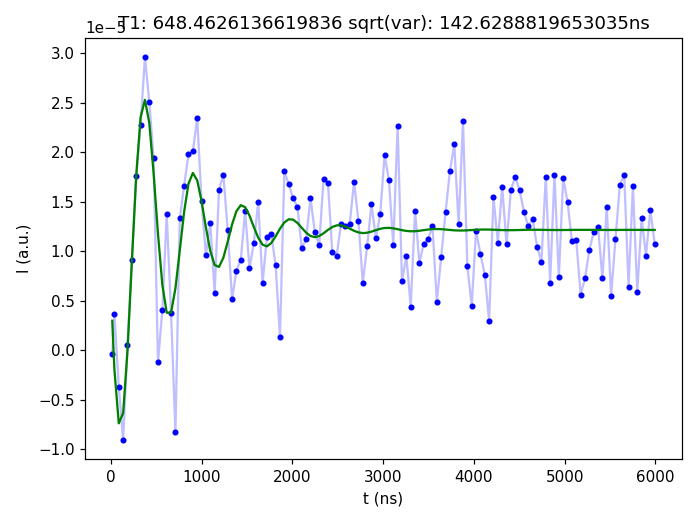

pguess [1.7837103553632116e-05, 1000, 0.0052429783938414435, -1.5707963267948966, 1.0262345739096794e-05]
[ 2.35316550e-05  6.48462614e+02  1.17280960e-02 -2.91840427e+00
  1.21549213e-05]
357.15858840717965
[ 2.35316550e-05  6.48462614e+02  1.17280960e-02 -2.91840427e+00
  1.21549213e-05]
Pi Half 357.15858840717965 ns
648.4626136619836
142.6288819653035


In [30]:
freq_det = 2.0e6
rotation_angle = 90*np.pi/180

folder = r'.\\Fig_4b\\'
folder = folder + r'T2_errorbars\\'
file = r'T2_Refl_highPower_saveAllPointsNoAvg_long_readout_pulse_pi_half_2023_05_31-15-36-39.mat'

data_file = folder + file

avg_from = 1600
avg_to = 2000

data = loadmat(data_file)
I = np.squeeze(data['I'])
Q = np.squeeze(data['Q'])
t_ns = np.squeeze(data['t_ns'])

# plt.figure()
# plt.plot(t_ns,I[0])
# plt.plot(t_ns,I[1000])
# plt.plot(t_ns,I[1999])
# plt.plot(t_ns,Q[0])
# plt.plot(t_ns,Q[1000])
# plt.plot(t_ns,Q[1999])
# plt.show()

# plt.figure()
# plt.plot(t_ns,np.mean(I,0))
# plt.show()

def fitfunction(t, A0, tau2, omega, phi, B0):
    if freq_det == 0:
        y = A0*np.exp(-t/tau2)*np.sin(0*omega*t+phi)+B0
    else:
        y = A0*np.exp(-t/tau2)*np.sin(omega*t+phi)+B0
    return y


res = minimize(minimizeQ, x0 = [0.5],args = (np.mean(I[avg_from:avg_to],0),np.mean(Q[avg_from:avg_to],0)))
rotation_angle_test = res.x[0]
print('rotated by: ' + str(rotation_angle_test) + ' rad')
print('rotated by: ' + str(180/np.pi*rotation_angle_test) + ' deg')
I_rot,Q_rot = rotatedata(np.mean(I[avg_from:avg_to],0),np.mean(Q[avg_from:avg_to],0),rotation_angle_test)


xdatafit = t_ns
ydatafit = I_rot

print('np.shape(xdatafit): ' + str(np.shape(xdatafit)))
print('np.shape(ydatafit): ' + str(np.shape(ydatafit)))

pguess = [(np.max(ydatafit)-np.mean(ydatafit)), 1000, 2*np.pi/(4*np.max(tvec)/5),np.pi/2*np.sign(ydatafit[0]-np.mean(ydatafit)),np.min(ydatafit)+(np.max(ydatafit)-np.min(ydatafit))/2]
boundslow = [np.min(ydatafit),100,np.min(ydatafit)]
boundshigh = [2*np.max(ydatafit),3000000,np.max(ydatafit)]
fig = plt.figure()
plt.plot(xdatafit, ydatafit,"b.")
plt.plot(xdatafit, ydatafit,"b-",alpha=0.25)
print('pguess ' + str(pguess))

try:
    popt, pcov = curve_fit(fitfunction, xdatafit, ydatafit, p0=pguess)
    print(popt)
    plt.plot(xdatafit, fitfunction(xdatafit, *popt), 'g-')
except:
    plt.plot(xdatafit, fitfunction(xdatafit, *pguess), 'r-')
    print('Fit unsuccessful with pguess: ' + str(pguess))
    print('Min bounds: ' + str(boundslow))
    print('Max bounds: ' + str(boundshigh))
    
ind_omegahalf = np.argmin(abs(xdatafit-(2*np.pi)/popt[2]/2.0))
xfine = np.linspace(0,(2*np.pi)/popt[2]/1.5)
if ydatafit[0]>ydatafit[ind_omegahalf]:
    pipulselen = xfine[np.argmin(fitfunction(xfine, *popt))]
    print(pipulselen)
else:
    pipulselen = xfine[np.argmax(fitfunction(xfine, *popt))]
    print(pipulselen)

mdict = {'popt': popt, 'pcov': pcov}
new_filename = folder + file[:-4] + '_fit_avg_' + str(avg_from) + '_' + str(avg_to)


plt.xlabel('t (ns)')
plt.ylabel('I (a.u.)')
plt.title('T1: ' + str(popt[1]) + ' sqrt(var): ' + str(np.sqrt(np.diag(pcov))[1]) + 'ns')
print(popt)
print('Pi Half ' + str(pipulselen) + ' ns')
plt.tight_layout()
# plt.savefig(new_filename + '_plot.png')
# savemat(new_filename + '_fitparams.mat', mdict)
plt.show()
print(str(popt[1]))
print(str(np.sqrt(np.diag(pcov))[1]))

In [39]:
array_T2_cold = np.asarray([1372.0576273175284,1411.1136180865294,1460.3825914241768,1455.3097049059763,1568.3410344782615])
array_T2_cold_var = np.asarray([62.753292004952016,73.04569596517379,82.207654681814,77.43351107453378,88.63850044739733])

print(np.mean(array_T2_cold))
print(np.std(array_T2_cold))

1453.4409152424946
65.83092932872579


In [41]:
array_T2_cold_new = np.asarray([1473.2450676996623,1467.6511442419694,1504.6459962603185,1577.9501589306176,1570.466534403443])
array_T2_cold_new_var = np.asarray([71.06254306639877,72.34080453663691,76.57899348772266,67.72850090549257,71.05600767111898])

np.mean(array_T2_cold_new),np.std(array_T2_cold_new,ddof=1)

(1518.791780307202, 52.583183778347355)

In [33]:
array_T2_10Hz = np.asarray([1389.646271034785,1356.5478028372531,1371.4315738628463,1416.951175699445,1479.403984156436])
array_T2_10Hz_var = np.asarray([69.02916502530812,72.8187480300035,66.615991252509,74.29753009013149,81.69976328115992])
np.mean(array_T2_10Hz),np.std(array_T2_10Hz,ddof=1)

(1402.7961615181532, 48.385665684788215)

In [34]:
array_T2_50Hz = np.asarray([1241.772942928333,1241.8688792134553,1147.806783708564,1186.502816000088,1260.0379661926688])
array_T2_50Hz_var = np.asarray([75.82942296756617,71.49507596682052,61.85771788940897,68.94559016593342,71.38331190858428])
np.mean(array_T2_50Hz),np.std(array_T2_50Hz,ddof=1)

(1215.5978776086217, 46.883835341568165)

In [35]:
array_T2_250Hz = np.asarray([761.8451428583176,717.762856121504,909.2543784711634,761.1240928041643,871.7499628774984])
array_T2_250Hz_var = np.asarray([68.85762936010703,62.767883934490925,70.86430411746348,60.63435610011543,68.40810770767902])
np.mean(array_T2_250Hz),np.std(array_T2_250Hz,ddof=1)

(804.3472866265296, 81.7315101415459)

In [36]:
array_T2_500Hz = np.asarray([572.9979533405843,520.9802789915507,644.5859010774716,627.5080522241382,519.8502240967334])
array_T2_500Hz_var = np.asarray([70.88279133718585,68.64758346361349,77.7301551484689,78.05271180799627,62.1587165756774])

np.mean(array_T2_500Hz),np.std(array_T2_500Hz,ddof=1)

(577.1844819460957, 58.17875385634797)

In [37]:
array_T2_1000Hz = np.asarray([675.1445364462725,275.5077294362064,477.1472788521793,476.52494435084685,648.4626136619836])
array_T2_1000Hz_var = np.asarray([147.13715953916721,53.6139968824389,96.28497043129568,149.04046678789223,142.6288819653035])

np.mean(array_T2_1000Hz),np.std(array_T2_1000Hz,ddof=1)

(510.5574205494977, 160.9577314883559)

## T1
Copied form "2023_7_10 - Qubit Coherence". This is the same file as used for the cells for T2 and T2*

Folder: .\\Fig_4b\\T1_internally_triggered\ found
Number of alpha-numeric in file path: 108
rotated by: -0.0805950516948266 rad
rotated by: -4.617756311752257 deg


<IPython.core.display.Javascript object>


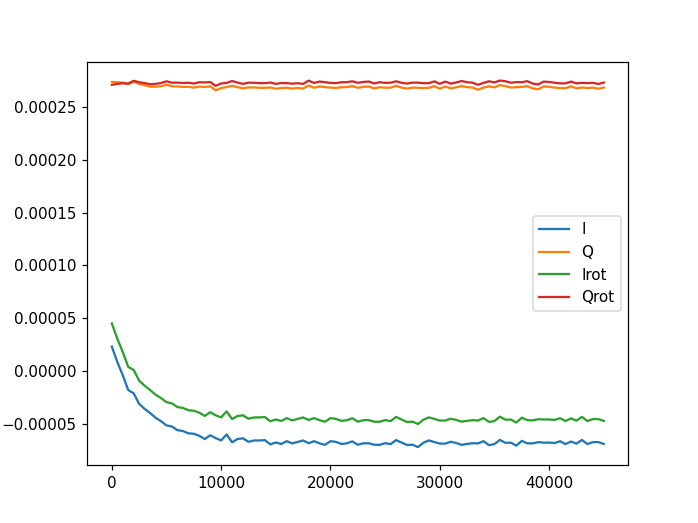

In [61]:
folder = r'.\\Fig_4b\\'
subfolder = 'T1_internally_triggered\\'
#cold
T1file = 'T1_Refl_JPA_TimeStampsAll_long_readout_pulse_pi_2023_05_01-11-00-42.mat'
#10Hz
T1file = 'T1_Refl_JPA_TimeStampsAll_long_readout_pulse_pi_2023_05_12-22-58-17.mat'
#50Hz
T1file = 'T1_Refl_JPA_TimeStampsAll_long_readout_pulse_pi_2023_05_16-08-24-52.mat'
#250Hz
T1file = 'T1_Refl_JPA_TimeStampsAll_long_readout_pulse_pi_2023_05_19-15-52-40.mat'
#500Hz
T1file = 'T1_Refl_JPA_TimeStampsAll_long_readout_pulse_x180_2023_05_24-13-49-16.mat'
#1000Hz
T1file = 'T1_Refl_JPA_TimeStampsAll_long_readout_pulse_x180_2023_05_31-15-09-56.mat'

# subfolder = 'T1_externally_triggered\\'
# T1file = 'T1_Refl_1000Hz144mK_ExtTrig_193260ns_25dBmWinAOMlong_readout_pulse_x180_2023_10_15-04-04-07.mat'
if os.path.isdir(folder + subfolder):
    print('Folder: ' + folder + subfolder + ' found')



print('Number of alpha-numeric in file path: ' + str(len(folder + subfolder + T1file)))
data = loadmat(folder + subfolder + T1file)
I = data['I'][0]
Q = data['Q'][0]

taus = data['t_ns'][0]/4
filename = T1file

freq_det = 2.0e6
rotation_angle = 90*np.pi/180
qubit_T1 = 40e3

res = minimize(minimizeQ, x0 = [0.5],args = (I,Q))
rotation_angle_test = res.x[0]
print('rotated by: ' + str(rotation_angle_test) + ' rad')
print('rotated by: ' + str(180/np.pi*rotation_angle_test) + ' deg')
I_rot,Q_rot = rotatedata(I,Q,rotation_angle_test)

plt.figure()
plt.plot(taus,I, label='I')
plt.plot(taus,Q, label='Q')
plt.plot(taus,I_rot, label='Irot')
plt.plot(taus,Q_rot, label='Qrot')
plt.legend()
plt.show()

np.shape(xdatafit): (91,)
np.shape(ydatafit): (91,)


<IPython.core.display.Javascript object>


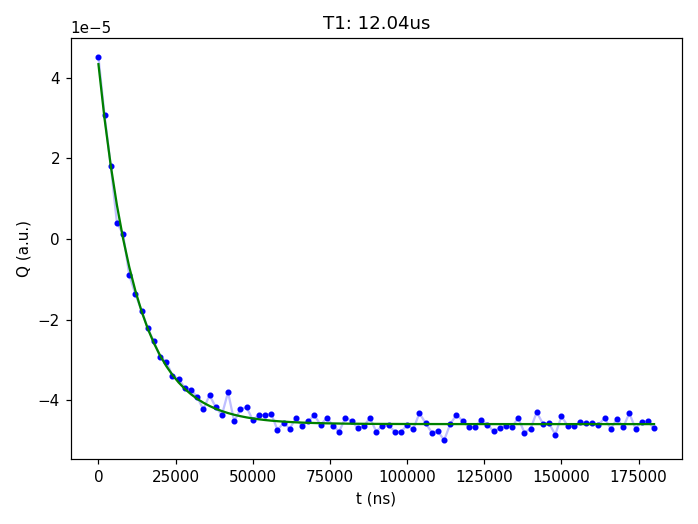

pguess [8.464398326533029e-05, 1000, -2.4010857583340003e-06]
[8.94154298e-05 1.20415131e+04 4.59271665e-05]
Fit succesful!
91205.06494404933
[8.94154298e-05 1.20415131e+04 4.59271665e-05]
Pi Half 91205.06494404933 ns
# of relaxations for T1 = 40000.0ns : 0.8191522930578408
popt:[8.94154298e-05 1.20415131e+04 4.59271665e-05]
pcov:[[ 1.19478645e-12 -1.54070473e-04  1.02404443e-14]
 [-1.54070473e-04  5.99400048e+04  1.83258776e-05]
 [ 1.02404443e-14  1.83258776e-05  3.66344063e-14]]
T1 -> popt[1]=12041.513105783635ns
Standard deviation T1 -> np.sqrt(np.diag(pcov))[1]:244.82647905724323


In [62]:
def fitfunction(t, A0, tau2, B0):
    return A0*np.exp(-t/tau2)-B0



xdatafit = 4*taus
ydatafit = I_rot
#ydatafit = np.sqrt(I**2 + Q**2)
print('np.shape(xdatafit): ' + str(np.shape(xdatafit)))
print('np.shape(ydatafit): ' + str(np.shape(ydatafit)))

pguess = [(np.max(ydatafit)-np.mean(ydatafit)), 1000,np.min(ydatafit)+(np.max(ydatafit)-np.min(ydatafit))/2]
boundslow = [np.min(ydatafit),3000,np.min(ydatafit)]
boundshigh = [2*np.max(ydatafit),3000000,np.max(ydatafit)]
fig = plt.figure()
plt.plot(xdatafit, ydatafit,"b.")
plt.plot(xdatafit, ydatafit,"b-",alpha=0.25)
#plt.plot(4*tvec, fitfunction(4*tvec, *pguess), 'b-')
print('pguess ' + str(pguess))

try:
    popt, pcov = curve_fit(fitfunction, xdatafit, ydatafit, p0=pguess)
    print(popt)
    plt.plot(xdatafit, fitfunction(xdatafit, *popt), 'g-')
    print('Fit succesful!')
except:
    plt.plot(xdatafit, fitfunction(xdatafit, *pguess), 'r-')
    print('Fit unsuccessful with pguess: ' + str(pguess))
    print('Min bounds: ' + str(boundslow))
    print('Max bounds: ' + str(boundshigh))
    
ind_omegahalf = np.argmin(abs(xdatafit-(2*np.pi)/popt[2]/2.0))
xfine = np.linspace(0,(2*np.pi)/popt[2]/1.5)
if ydatafit[0]>ydatafit[ind_omegahalf]:
    pipulselen = xfine[np.argmin(fitfunction(xfine, *popt))]
#     pipulselenMod4 = 4*tvec[np.argmin(fitfunction(xdatafit[0:int(ind_omegahalf*1.5)], *popt))]
    print(pipulselen)
#     print(pipulselenMod4)
else:
    pipulselen = xfine[np.argmax(fitfunction(xfine, *popt))]
#     pipulselenMod4 = xdatafit[np.argmax(fitfunction(xdatafit[0:int(ind_omegahalf*1.5)], *popt))]
    print(pipulselen)

# plt.vlines(pipulselen, np.min(ydatafit),np.max(ydatafit), color = 'gray', linestyle = 'dashed')
# plt.vlines(pipulselenMod4, np.min(ydatafit),np.max(ydatafit), color = 'black', linestyle = 'dashed')
# plt.text(pipulselen+10,np.min(ydatafit) + (np.max(ydatafit)-np.min(ydatafit))*0.8, 'Pi/2: ' + str(np.round(pipulselen,1)) + ' ns', color = 'black', size = '10')
# plt.text(pipulselenMod4+10,np.min(ydatafit) + (np.max(ydatafit)-np.min(ydatafit))*0.9, 'Pi/2 Mod4: ' + str(np.round(pipulselenMod4,1)) + ' ns', color = 'black', size = '10')
plt.xlabel('t (ns)')
plt.ylabel('Q (a.u.)')
plt.title('T1: ' + str(np.round(popt[1]*1e-3,2)) + 'us')
print(popt)
print('Pi Half ' + str(pipulselen) + ' ns')
# print('Pi Half mod4: ' + str(pipulselenMod4) + ' ns')
plt.tight_layout()
plt.show()
print('# of relaxations for T1 = ' + str(qubit_T1) + 'ns : ' + str(1-np.exp(-4*np.round((2*np.pi)/popt[2]/2/4)/qubit_T1)))

print('popt:' + str(popt))
print('pcov:' + str(pcov))
print('T1 -> popt[1]=' + str(popt[1]) + 'ns')
print('Standard deviation T1 -> np.sqrt(np.diag(pcov))[1]:' + str(np.sqrt(np.diag(pcov))[1]))

### Fitting data to a file which saved all curves

rotated by: -0.05979660152331405 rad
rotated by: -3.4260928965114443 deg
np.shape(xdatafit): (91,)
np.shape(ydatafit): (91,)


<IPython.core.display.Javascript object>


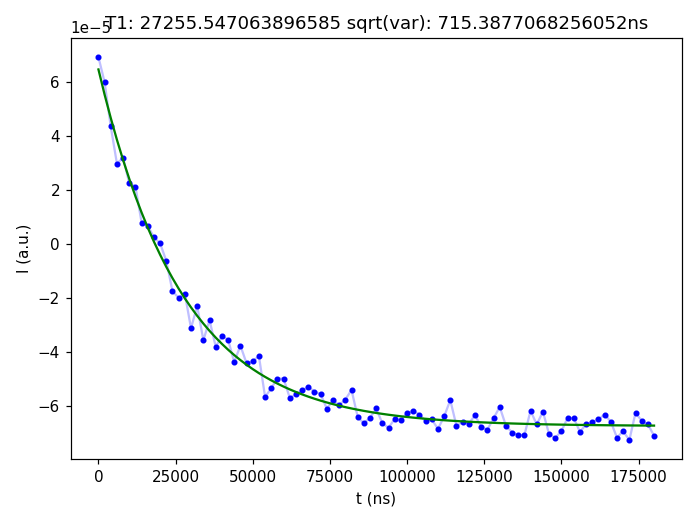

pguess [0.00011626352369171037, 1000, -1.7809908051901851e-06]
[1.32272265e-04 2.72555471e+04 6.75442067e-05]
62015.53633390563
[1.32272265e-04 2.72555471e+04 6.75442067e-05]
Pi Half 62015.53633390563 ns
# of relaxations for T1 = 40000.0ns : 0.687390352704176


In [124]:
folder = r'.\\Fig_4b\\'
folder = folder + r'T1_errorbars\\'
#0Hz
# file = r'T1_Refl_JPA_TimeStampsAll_long_readout_pulse_pi_2023_05_01-11-15-02.mat'
#10Hz
# file = r'T1_Refl_JPA_Alltraceslong_readout_pulse_pi_2023_05_12-23-04-30.mat'
#50Hz
# file = r'T1_Refl_JPA_Alltraces_long_readout_pulse_pi_2023_05_16-08-28-17.mat'
#250Hz
file = r'T1_Refl_JPA_Alltraces_long_readout_pulse_pi_2023_05_19-15-42-41.mat'
#50Hz
# file = r'T1_Refl_JPA_Alltraces_long_readout_pulse_pi_2023_05_24-13-41-25.mat'
#1000
# file = r'T1_Refl_JPA_Alltraces_long_readout_pulse_pi_2023_05_31-15-14-07.mat'




data_file = folder + file

avg_from = 0
avg_to = 400

data = loadmat(data_file)
I = np.squeeze(data['I'])
Q = np.squeeze(data['Q'])
t_ns = np.squeeze(data['t_ns'])

# plt.figure()
# plt.plot(t_ns,I[0])
# plt.plot(t_ns,I[1000])
# plt.plot(t_ns,I[1999])
# plt.plot(t_ns,Q[0])
# plt.plot(t_ns,Q[1000])
# plt.plot(t_ns,Q[1999])
# plt.show()

# plt.figure()
# plt.plot(t_ns,np.mean(I,0))
# plt.show()

def fitfunction(t, A0, tau2, B0):
    return A0*np.exp(-t/tau2)-B0


res = minimize(minimizeQ, x0 = [0.5],args = (np.mean(I[avg_from:avg_to],0),np.mean(Q[avg_from:avg_to],0)))
rotation_angle_test = res.x[0]
print('rotated by: ' + str(rotation_angle_test) + ' rad')
print('rotated by: ' + str(180/np.pi*rotation_angle_test) + ' deg')
I_rot,Q_rot = rotatedata(np.mean(I[avg_from:avg_to],0),np.mean(Q[avg_from:avg_to],0),rotation_angle_test)


xdatafit = t_ns
ydatafit = I_rot

print('np.shape(xdatafit): ' + str(np.shape(xdatafit)))
print('np.shape(ydatafit): ' + str(np.shape(ydatafit)))

pguess = [(np.max(ydatafit)-np.mean(ydatafit)), 1000,np.min(ydatafit)+(np.max(ydatafit)-np.min(ydatafit))/2]
boundslow = [np.min(ydatafit),100,np.min(ydatafit)]
boundshigh = [2*np.max(ydatafit),3000000,np.max(ydatafit)]
fig = plt.figure()
plt.plot(xdatafit, ydatafit,"b.")
plt.plot(xdatafit, ydatafit,"b-",alpha=0.25)
print('pguess ' + str(pguess))

try:
    popt, pcov = curve_fit(fitfunction, xdatafit, ydatafit, p0=pguess)
    print(popt)
    plt.plot(xdatafit, fitfunction(xdatafit, *popt), 'g-')
except:
    plt.plot(xdatafit, fitfunction(xdatafit, *pguess), 'r-')
    print('Fit unsuccessful with pguess: ' + str(pguess))
    print('Min bounds: ' + str(boundslow))
    print('Max bounds: ' + str(boundshigh))
    
ind_omegahalf = np.argmin(abs(xdatafit-(2*np.pi)/popt[2]/2.0))
xfine = np.linspace(0,(2*np.pi)/popt[2]/1.5)
if ydatafit[0]>ydatafit[ind_omegahalf]:
    pipulselen = xfine[np.argmin(fitfunction(xfine, *popt))]
    print(pipulselen)
else:
    pipulselen = xfine[np.argmax(fitfunction(xfine, *popt))]
    print(pipulselen)

mdict = {'popt': popt, 'pcov': pcov}
new_filename = folder + file[:-4] + '_fit_avg_' + str(avg_from) + '_' + str(avg_to)


plt.xlabel('t (ns)')
plt.ylabel('I (a.u.)')
plt.title('T1: ' + str(popt[1]) + ' sqrt(var): ' + str(np.sqrt(np.diag(pcov))[1]) + 'ns')
print(popt)
print('Pi Half ' + str(pipulselen) + ' ns')
plt.tight_layout()
# plt.savefig(new_filename + '_plot.png')
# savemat(new_filename + '_fitparams.mat', mdict)
plt.show()
print('# of relaxations for T1 = ' + str(qubit_T1) + 'ns : ' + str(1-np.exp(-4*np.round((2*np.pi)/popt[2]/2/4)/qubit_T1)))

In [140]:
ddof_temp = 1
#0Hz
mean_array = [38.4,38.2,41.6,37.9,42.6]
np.mean(mean_array),np.std(mean_array,ddof=ddof_temp)

(39.739999999999995, 2.190433747000809)

In [141]:
#10Hz
mean_array = [34.7,35.7,35.8,35.0,35.0]
np.mean(mean_array),np.std(mean_array,ddof=ddof_temp)

(35.239999999999995, 0.4827007354458859)

In [142]:
#50Hz
mean_array = [36.8,37.4,36.4,38.6,37.6]
np.mean(mean_array),np.std(mean_array,ddof=ddof_temp)

(37.36, 0.8414273587185066)

In [143]:
#250Hz
mean_array = [27.3,26.8,24.7,26,26]
np.mean(mean_array),np.std(mean_array,ddof=ddof_temp)

(26.160000000000004, 0.9864076236526161)

In [144]:
#500Hz
mean_array = [20.5,21.4,21.4,20.1,21.2]
np.mean(mean_array),np.std(mean_array,ddof=ddof_temp)

(20.92, 0.5890670590009245)

In [145]:
#1000Hz
mean_array = [10.9,14.3,14.0,12.9,13.2]
np.mean(mean_array),np.std(mean_array,ddof=ddof_temp)

(13.059999999999999, 1.3352902306240393)